In [1]:
import os
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split, GridSearchCV, RandomizedSearchCV, StratifiedKFold, cross_val_score
)
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)
from scipy.stats import loguniform

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [2]:
# same location as Exp 2 — falls back to the notebook's own folder if it isn't found there
DATA_PATH = "/home/mtech1/Downloads/Exp1/emailspam/spambase.csv"
if not os.path.exists(DATA_PATH):
    DATA_PATH = "spambase.csv"

df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
df.head()

Shape: (4601, 58)


,class,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,...,word_freq_conference,char_freq_semicolon,char_freq_(,char_freq_[,char_freq_!,char_freq_$,char_freq_#,capital_run_length_average,capital_run_length_longest,capital_run_length_total
0,1,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,...,0.0,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278
1,1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,...,0.0,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028
2,1,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,...,0.0,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259
3,1,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,...,0.0,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40,191
4,1,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,...,0.0,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40,191


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4601 entries, 0 to 4600
Data columns (total 58 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   class                       4601 non-null   int64  
 1   word_freq_make              4601 non-null   float64
 2   word_freq_address           4601 non-null   float64
 3   word_freq_all               4601 non-null   float64
 4   word_freq_3d                4601 non-null   float64
 5   word_freq_our               4601 non-null   float64
 6   word_freq_over              4601 non-null   float64
 7   word_freq_remove            4601 non-null   float64
 8   word_freq_internet          4601 non-null   float64
 9   word_freq_order             4601 non-null   float64
 10  word_freq_mail              4601 non-null   float64
 11  word_freq_receive           4601 non-null   float64
 12  word_freq_will              4601 non-null   float64
 13  word_freq_people            4601 non-null   

Column `class` is the target (1 = spam, 0 = ham); the remaining 57 columns are word/character frequency
features and three "capital run length" features describing runs of capital letters.

In [4]:
print("Missing values:", df.isna().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

Missing values: 0
Duplicate rows: 391


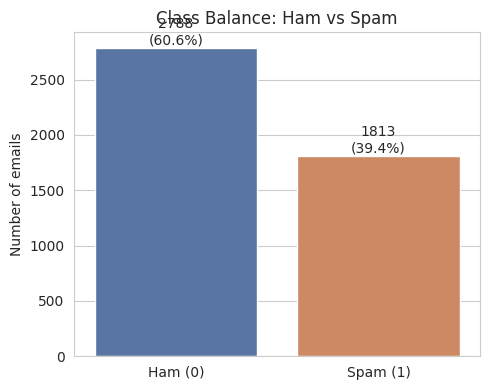

class
0    2788
1    1813
Name: count, dtype: int64


In [5]:
class_counts = df['class'].value_counts().sort_index()
class_pct = df['class'].value_counts(normalize=True).sort_index() * 100

fig, ax = plt.subplots(figsize=(5, 4))
sns.barplot(x=['Ham (0)', 'Spam (1)'], y=class_counts.values, ax=ax, palette=['#4C72B0', '#DD8452'])
for i, (c, p) in enumerate(zip(class_counts.values, class_pct.values)):
    ax.text(i, c + 30, f"{c}\n({p:.1f}%)", ha='center')
ax.set_ylabel("Number of emails")
ax.set_title("Class Balance: Ham vs Spam")
plt.tight_layout()
plt.show()

print(class_counts)

In [6]:
df.describe().T.loc[['word_freq_free', 'word_freq_your', 'char_freq_$',
                       'capital_run_length_average', 'capital_run_length_total']]

,count,mean,std,min,25%,50%,75%,max
word_freq_free,4601.0,0.248848,0.825792,0.0,0.000,0.000,0.100,20.000
word_freq_your,4601.0,0.809761,1.200810,0.0,0.000,0.220,1.270,11.110
char_freq_$,4601.0,0.075811,0.245882,0.0,0.000,0.000,0.052,6.003
capital_run_length_average,4601.0,5.191515,31.729449,1.0,1.588,2.276,3.706,1102.500
capital_run_length_total,4601.0,283.289285,606.347851,1.0,35.000,95.000,266.000,15841.000


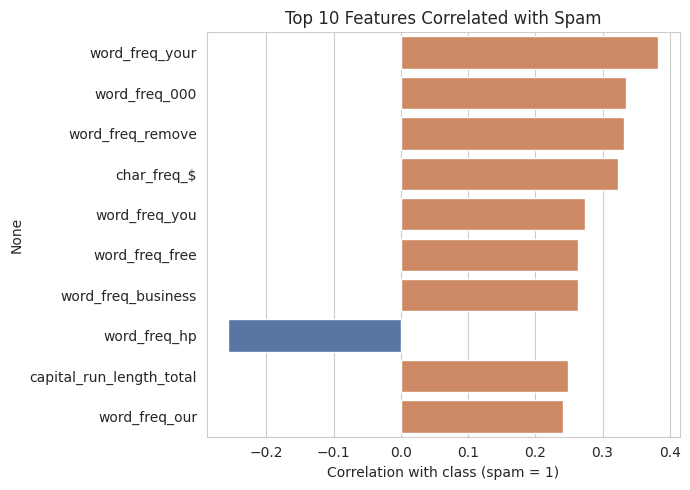

word_freq_your              0.383234
word_freq_000               0.334787
word_freq_remove            0.332117
char_freq_$                 0.323629
word_freq_you               0.273651
word_freq_free              0.263215
word_freq_business          0.263204
word_freq_hp               -0.256723
capital_run_length_total    0.249164
word_freq_our               0.241920
Name: class, dtype: float64

In [7]:
corr_with_target = df.corr(numeric_only=True)['class'].drop('class')
top_corr = corr_with_target.reindex(corr_with_target.abs().sort_values(ascending=False).index).head(10)

fig, ax = plt.subplots(figsize=(7, 5))
colors = ['#DD8452' if v > 0 else '#4C72B0' for v in top_corr.values]
sns.barplot(x=top_corr.values, y=top_corr.index, ax=ax, palette=colors)
ax.set_xlabel("Correlation with class (spam = 1)")
ax.set_title("Top 10 Features Correlated with Spam")
plt.tight_layout()
plt.show()

top_corr

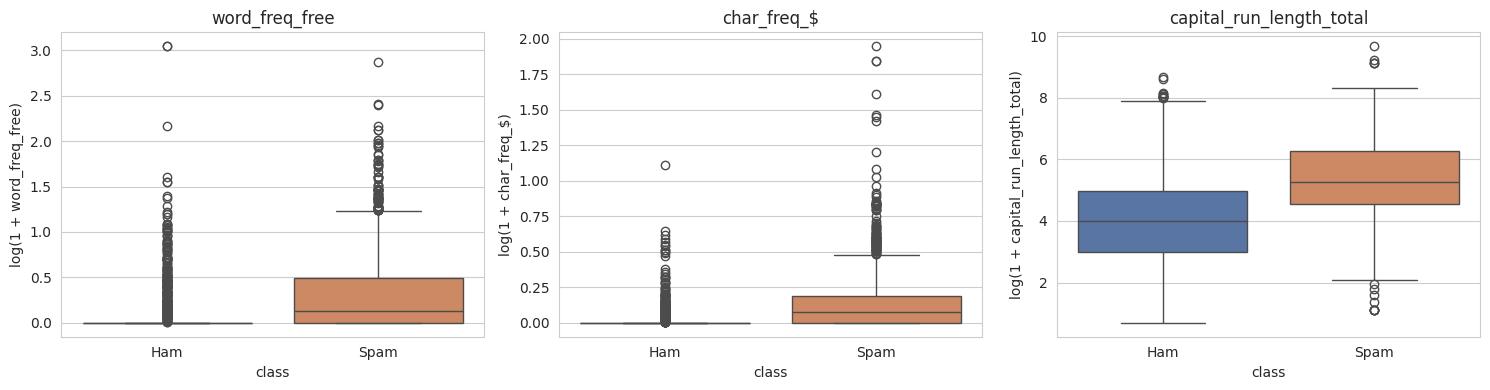

,word_freq_free,char_freq_$,capital_run_length_total
class,,,
0,0.073587,0.011648,161.470947
1,0.518362,0.174478,470.619415


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
feats = ['word_freq_free', 'char_freq_$', 'capital_run_length_total']
for ax, feat in zip(axes, feats):
    # log1p just to tame the heavy skew in these frequency features for the plot
    sns.boxplot(x=df['class'], y=np.log1p(df[feat]), ax=ax, palette=['#4C72B0', '#DD8452'])
    ax.set_xticklabels(['Ham', 'Spam'])
    ax.set_title(feat)
    ax.set_ylabel(f"log(1 + {feat})")
plt.tight_layout()
plt.show()

df.groupby('class')[feats].mean()

In [9]:
X = df.drop(columns=['class'])
y = df['class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (3680, 57)  Test: (921, 57)


In [10]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

In [11]:
t0 = time.time()
lr_baseline = LogisticRegression(max_iter=3000, tol=1e-3, random_state=RANDOM_STATE)
lr_baseline.fit(X_train_s, y_train)
lr_baseline_time = time.time() - t0

pred = lr_baseline.predict(X_test_s)
lr_baseline_metrics = {
    'accuracy': accuracy_score(y_test, pred),
    'precision': precision_score(y_test, pred),
    'recall': recall_score(y_test, pred),
    'f1': f1_score(y_test, pred),
    'time': lr_baseline_time,
}
lr_baseline_metrics

{'accuracy': 0.9283387622149837,
 'precision': 0.9183098591549296,
 'recall': 0.8980716253443526,
 'f1': 0.9080779944289693,
 'time': 0.012386083602905273}

In [12]:
param_grid_lr = [
    {'penalty': ['l1'], 'C': [0.01, 0.1, 1, 10, 100], 'solver': ['liblinear', 'saga']},
    {'penalty': ['l2'], 'C': [0.01, 0.1, 1, 10, 100], 'solver': ['liblinear', 'saga']},
]

t0 = time.time()
grid_lr = GridSearchCV(
    LogisticRegression(max_iter=3000, tol=1e-3, random_state=RANDOM_STATE),
    param_grid_lr, cv=5, scoring='accuracy', n_jobs=1
)
grid_lr.fit(X_train_s, y_train)
grid_lr_time = time.time() - t0

print("Best params (Grid):", grid_lr.best_params_)
print("Best CV accuracy (Grid):", round(grid_lr.best_score_, 4))
print(f"Search time: {grid_lr_time:.1f}s")

Best params (Grid): {'C': 10, 'penalty': 'l2', 'solver': 'saga'}
Best CV accuracy (Grid): 0.9239
Search time: 24.6s


In [13]:
param_dist_lr = {
    'penalty': ['l1', 'l2'],
    'C': loguniform(1e-2, 1e2),
    'solver': ['liblinear', 'saga'],
}

t0 = time.time()
random_lr = RandomizedSearchCV(
    LogisticRegression(max_iter=3000, tol=1e-3, random_state=RANDOM_STATE),
    param_dist_lr, n_iter=15, cv=5, scoring='accuracy',
    random_state=RANDOM_STATE, n_jobs=1
)
random_lr.fit(X_train_s, y_train)
random_lr_time = time.time() - t0

print("Best params (Random):", random_lr.best_params_)
print("Best CV accuracy (Random):", round(random_lr.best_score_, 4))
print(f"Search time: {random_lr_time:.1f}s")

Best params (Random): {'C': np.float64(2.342384984711291), 'penalty': 'l1', 'solver': 'liblinear'}
Best CV accuracy (Random): 0.9242
Search time: 12.1s


In [14]:
best_lr_search = grid_lr if grid_lr.best_score_ >= random_lr.best_score_ else random_lr
chosen_method = "Grid Search" if best_lr_search is grid_lr else "Randomized Search"
best_lr = best_lr_search.best_estimator_

t0 = time.time()
best_lr.fit(X_train_s, y_train)
lr_tuned_time = time.time() - t0

pred = best_lr.predict(X_test_s)
lr_tuned_metrics = {
    'accuracy': accuracy_score(y_test, pred),
    'precision': precision_score(y_test, pred),
    'recall': recall_score(y_test, pred),
    'f1': f1_score(y_test, pred),
    'time': lr_tuned_time,
}
print("Chosen via:", chosen_method, "-", best_lr_search.best_params_)
lr_tuned_metrics

Chosen via: Randomized Search - {'C': np.float64(2.342384984711291), 'penalty': 'l1', 'solver': 'liblinear'}


{'accuracy': 0.9261672095548317,
 'precision': 0.9178470254957507,
 'recall': 0.8925619834710744,
 'f1': 0.9050279329608939,
 'time': 0.09516072273254395}

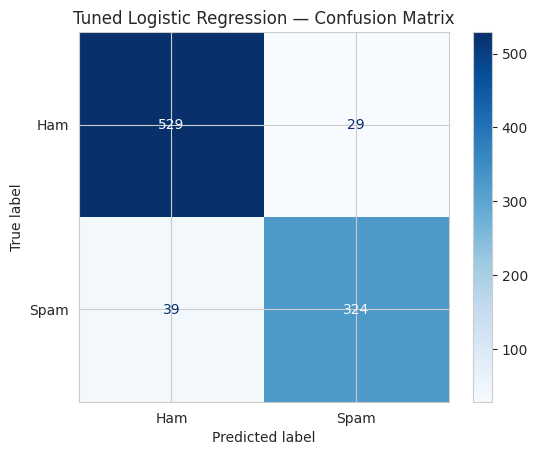

              precision    recall  f1-score   support

         Ham       0.93      0.95      0.94       558
        Spam       0.92      0.89      0.91       363

    accuracy                           0.93       921
   macro avg       0.92      0.92      0.92       921
weighted avg       0.93      0.93      0.93       921



In [15]:
cm = confusion_matrix(y_test, best_lr.predict(X_test_s))
ConfusionMatrixDisplay(cm, display_labels=['Ham', 'Spam']).plot(cmap='Blues')
plt.title("Tuned Logistic Regression — Confusion Matrix")
plt.show()

print(classification_report(y_test, best_lr.predict(X_test_s), target_names=['Ham', 'Spam']))

In [16]:
kernel_rows = []
for k in ['linear', 'poly', 'rbf', 'sigmoid']:
    t0 = time.time()
    model = SVC(kernel=k, degree=3, random_state=RANDOM_STATE)
    model.fit(X_train_s, y_train)
    fit_time = time.time() - t0
    pred = model.predict(X_test_s)
    kernel_rows.append({
        'kernel': k,
        'accuracy': accuracy_score(y_test, pred),
        'f1': f1_score(y_test, pred),
        'time': fit_time,
    })

kernel_df = pd.DataFrame(kernel_rows).set_index('kernel')
kernel_df

,accuracy,f1,time
kernel,,,
linear,0.929425,0.909344,0.471200
poly,0.779587,0.621974,0.413597
rbf,0.927253,0.905501,0.203514
sigmoid,0.884908,0.852778,0.250504


In [17]:
param_grid_svm = [
    {'kernel': ['linear'], 'C': [0.1, 1, 10, 100]},
    {'kernel': ['rbf'], 'C': [0.1, 1, 10, 100], 'gamma': ['scale', 'auto']},
    {'kernel': ['sigmoid'], 'C': [0.1, 1, 10, 100], 'gamma': ['scale', 'auto']},
    {'kernel': ['poly'], 'C': [0.1, 1, 10, 100], 'gamma': ['scale', 'auto'], 'degree': [2, 3, 4]},
]

t0 = time.time()
grid_svm = GridSearchCV(
    SVC(random_state=RANDOM_STATE), param_grid_svm, cv=5, scoring='accuracy', n_jobs=1
)
grid_svm.fit(X_train_s, y_train)
grid_svm_time = time.time() - t0

print("Best params:", grid_svm.best_params_)
print("Best CV accuracy:", round(grid_svm.best_score_, 4))
print(f"Search time: {grid_svm_time:.1f}s")

Best params: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Best CV accuracy: 0.9332
Search time: 106.0s


In [18]:
best_svm = grid_svm.best_estimator_

t0 = time.time()
best_svm.fit(X_train_s, y_train)
svm_tuned_time = time.time() - t0

pred = best_svm.predict(X_test_s)
svm_tuned_metrics = {
    'accuracy': accuracy_score(y_test, pred),
    'precision': precision_score(y_test, pred),
    'recall': recall_score(y_test, pred),
    'f1': f1_score(y_test, pred),
    'time': svm_tuned_time,
}
svm_tuned_metrics

{'accuracy': 0.9207383279044516,
 'precision': 0.9142857142857143,
 'recall': 0.8815426997245179,
 'f1': 0.8976157082748948,
 'time': 0.19759488105773926}

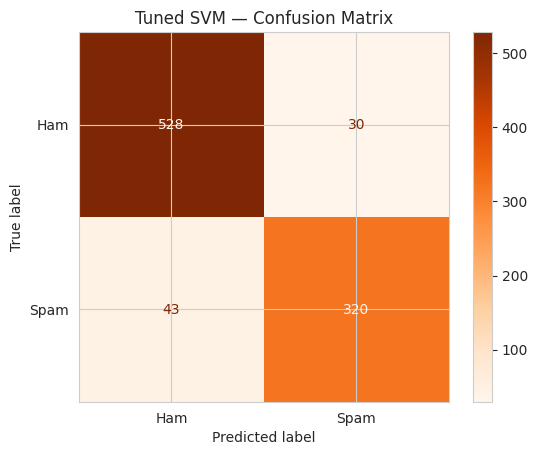

              precision    recall  f1-score   support

         Ham       0.92      0.95      0.94       558
        Spam       0.91      0.88      0.90       363

    accuracy                           0.92       921
   macro avg       0.92      0.91      0.92       921
weighted avg       0.92      0.92      0.92       921



In [19]:
cm = confusion_matrix(y_test, best_svm.predict(X_test_s))
ConfusionMatrixDisplay(cm, display_labels=['Ham', 'Spam']).plot(cmap='Oranges')
plt.title("Tuned SVM — Confusion Matrix")
plt.show()

print(classification_report(y_test, best_svm.predict(X_test_s), target_names=['Ham', 'Spam']))

In [20]:
X_all_s = StandardScaler().fit_transform(X)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_lr = cross_val_score(best_lr, X_all_s, y, cv=skf, scoring='accuracy')
cv_svm = cross_val_score(best_svm, X_all_s, y, cv=skf, scoring='accuracy')

cv_table = pd.DataFrame({
    'Logistic Regression': list(cv_lr) + [cv_lr.mean()],
    'SVM (RBF)': list(cv_svm) + [cv_svm.mean()],
}, index=[f"Fold {i+1}" for i in range(5)] + ["Average"])

cv_table.round(4)

,Logistic Regression,SVM (RBF)
Fold 1,0.9164,0.9305
Fold 2,0.9348,0.9293
Fold 3,0.9304,0.9413
Fold 4,0.9304,0.9326
Fold 5,0.9272,0.9370
Average,0.9278,0.9341


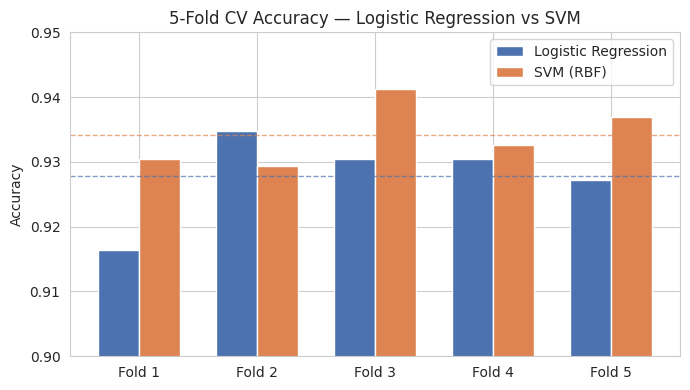

In [21]:
fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(5)
width = 0.35
ax.bar(x - width/2, cv_lr, width, label='Logistic Regression', color='#4C72B0')
ax.bar(x + width/2, cv_svm, width, label='SVM (RBF)', color='#DD8452')
ax.axhline(cv_lr.mean(), color='#4C72B0', linestyle='--', linewidth=1, alpha=0.7)
ax.axhline(cv_svm.mean(), color='#DD8452', linestyle='--', linewidth=1, alpha=0.7)
ax.set_xticks(x)
ax.set_xticklabels([f"Fold {i+1}" for i in range(5)])
ax.set_ylim(0.9, 0.95)
ax.set_ylabel("Accuracy")
ax.set_title("5-Fold CV Accuracy — Logistic Regression vs SVM")
ax.legend()
plt.tight_layout()
plt.show()

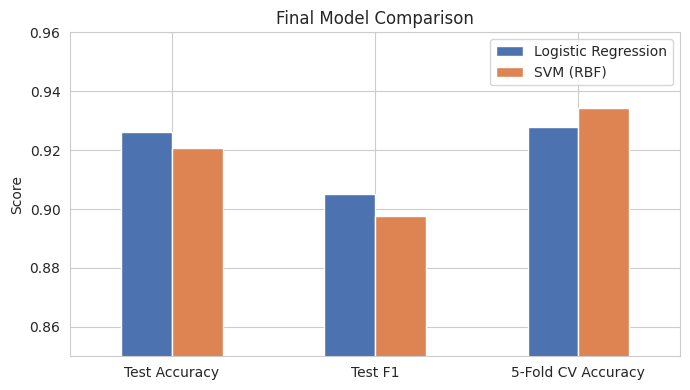

,Logistic Regression,SVM (RBF)
Test Accuracy,0.9262,0.9207
Test F1,0.9050,0.8976
5-Fold CV Accuracy,0.9278,0.9341


In [22]:
summary_df = pd.DataFrame({
    'Logistic Regression': [lr_tuned_metrics['accuracy'], lr_tuned_metrics['f1'], cv_lr.mean()],
    'SVM (RBF)': [svm_tuned_metrics['accuracy'], svm_tuned_metrics['f1'], cv_svm.mean()],
}, index=['Test Accuracy', 'Test F1', '5-Fold CV Accuracy'])

summary_df.plot(kind='bar', figsize=(7, 4), color=['#4C72B0', '#DD8452'], rot=0)
plt.ylim(0.85, 0.96)
plt.ylabel("Score")
plt.title("Final Model Comparison")
plt.tight_layout()
plt.show()

summary_df.round(4)